In [1]:
import os
import sys

# Get the current directory (Graphs folder)
current_dir = os.getcwd()
# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
# Add the parent directory to the sys.path
sys.path.append(parent_dir)
# Now you can import the RQAOA module


from utils import *
from graphs import *
from RQAOA import *
from solvers import *
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import itertools
import concurrent.futures

In [2]:
@jit(nopython=True)
def calculate_cost(edges, adj_mat, assignment):
    cost = 0
    for u, v in edges:
        cost += adj_mat[u, v] * assignment[u] * assignment[v]
    return cost

def brute_force_costs(edges, adj_mat):
    num_nodes = adj_mat.shape[0]
    possible_assignments = itertools.product([-1, 1], repeat=num_nodes)
    unique_costs = set()

    for assignment in possible_assignments:
        cost = calculate_cost(edges, adj_mat, np.array(assignment))
        unique_costs.add(cost)

    return sorted(unique_costs)

In [3]:
# Initialize dictionaries
max_freq_H = {i: [] for i in range(2, 20)}
max_freq_QAOA = {i: [] for i in range(2, 20)}

def process_graph(d, i):
    graph = generate_d_regular_graph(20, d, seed=42*i, fields=False, e_dist=[50, 25], n_dist=None)
    edges, adj_mat = graph_to_array(graph)
    QAOA_Freq = get_max_frequency(edges, adj_mat)
    
    eigenvalues = brute_force_costs(edges, adj_mat)
    H_Freq = max(eigenvalues) - min(eigenvalues)
    
    return QAOA_Freq, H_Freq

def parallel_process(d, max_processes=8):
    with concurrent.futures.ProcessPoolExecutor(max_workers=max_processes) as executor:
        futures = [executor.submit(process_graph, d, i) for i in range(100)]
        for future in concurrent.futures.as_completed(futures):
            QAOA_Freq, H_Freq = future.result()
            max_freq_QAOA[d].append(QAOA_Freq)
            max_freq_H[d].append(H_Freq)
    
    print(f"Finished for d={d}.")

# Example of running the loop with parallel processing
max_processes = 12

for d in range(2, 20):
    parallel_process(d, max_processes)

Finished for d=2.
Finished for d=3.
Finished for d=4.
Finished for d=5.
Finished for d=6.
Finished for d=7.
Finished for d=8.
Finished for d=9.
Finished for d=10.
Finished for d=11.
Finished for d=12.
Finished for d=13.
Finished for d=14.
Finished for d=15.
Finished for d=16.
Finished for d=17.
Finished for d=18.
Finished for d=19.


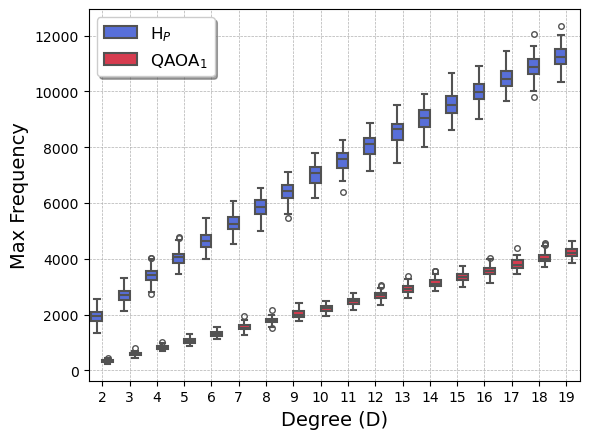

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare the data for plotting
data = []
for d in range(2, 20):
    for freq in max_freq_H[d]:
        data.append({'Degree (d)': d, 'Max Frequency': freq, 'Method': r'H$_P$'})
    for freq in max_freq_QAOA[d]:
        data.append({'Degree (d)': d, 'Max Frequency': freq, 'Method': r'QAOA$_1$'})

# Convert to a DataFrame for easier plotting
df = pd.DataFrame(data)

# Set the aesthetic style of the plots
#sns.set(style="whitegrid")

# Define a custom color palette
palette = sns.color_palette(["#4361ee", "#ef233c"])

# Create the boxplot with enhanced aesthetics
plt.figure(figsize=(6, 4.5))
sns.boxplot(x='Degree (d)', y='Max Frequency', hue='Method', data=df, palette=palette, fliersize=4, linewidth=1.5)

# Add grid lines and a title
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Set labels with increased font size
plt.xlabel('Degree (D)', fontsize=14)
plt.ylabel('Max Frequency', fontsize=14)

# Adjust legend position and style
plt.legend(loc='upper left', frameon=True, fontsize=12, fancybox=True, shadow=True)

# Tight layout to minimize padding
plt.tight_layout()
plt.savefig('freq_diff_qaoa1_deg.pdf', bbox_inches='tight')
# Display the plot
plt.show()


In [8]:
# Initialize dictionaries
max_freq_H_size = {n: [] for n in range(5, 21)}
max_freq_QAOA_size = {n: [] for n in range(5, 21)}

def process_graph(n, d, i):
    graph = generate_d_regular_graph(n, d, seed=42*i, fields=False, e_dist=[50, 20], n_dist=None)
    edges, adj_mat = graph_to_array(graph)
    QAOA_Freq = get_max_frequency(edges, adj_mat)
    
    eigenvalues = brute_force_costs(edges, adj_mat)
    H_Freq = max(eigenvalues) - min(eigenvalues)
    
    return QAOA_Freq, H_Freq

def parallel_process(n, d=4, max_processes=8):
    with concurrent.futures.ProcessPoolExecutor(max_workers=max_processes) as executor:
        futures = [executor.submit(process_graph, n, d, i) for i in range(100)]
        for future in concurrent.futures.as_completed(futures):
            QAOA_Freq, H_Freq = future.result()
            max_freq_QAOA_size[n].append(QAOA_Freq)
            max_freq_H_size[n].append(H_Freq)
    
    print(f"Finished for n={n}.")

# Example of running the loop with parallel processing
max_processes = 1

for n in range(5, 21):
    parallel_process(n, d=4, max_processes=max_processes)


Finished for n=5.
Finished for n=6.
Finished for n=7.
Finished for n=8.
Finished for n=9.
Finished for n=10.
Finished for n=11.
Finished for n=12.
Finished for n=13.
Finished for n=14.
Finished for n=15.
Finished for n=16.


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare the data for plotting
data2 = []
for d in range(5, 21):
    for freq in max_freq_H_size[d]:
        data2.append({'Degree (d)': d, 'Max Frequency': freq, 'Method': r'H$_P$'})
    for freq in max_freq_QAOA_size[d]:
        data2.append({'Degree (d)': d, 'Max Frequency': freq, 'Method': r'QAOA$_1$'})

# Convert to a DataFrame for easier plotting
df2 = pd.DataFrame(data2)

# Set the aesthetic style of the plots
#sns.set(style="whitegrid")

# Define a custom color palette
palette = sns.color_palette(["#4361ee", "#ef233c"])

# Create the boxplot with enhanced aesthetics
plt.figure(figsize=(6, 4.5))
sns.boxplot(x='Degree (d)', y='Max Frequency', hue='Method', data=df2, palette=palette, fliersize=4, linewidth=1.5)

# Add grid lines and a title
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Set labels with increased font size
plt.xlabel('# Nodes', fontsize=14)
plt.ylabel('Max Frequency', fontsize=14)

# Adjust legend position and style
plt.legend(loc='upper left', frameon=True, fontsize=12, fancybox=True, shadow=True)

# Tight layout to minimize padding
plt.tight_layout()
plt.savefig('freq_diff_qaoa1_nodes.pdf', bbox_inches='tight')
# Display the plot
plt.show()


In [ ]:
plt.figure(figsize=(6, 5))
palette = sns.color_palette(["#4361ee", "#ef233c"])
sns.stripplot(x='Degree (d)', y='Max Frequency', hue='Method', data=df2, palette=palette, jitter=True, dodge=False, size=5, alpha=0.7, edgecolor='black')

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlabel('# Nodes', fontsize=14)
plt.ylabel('Max Frequency', fontsize=14)
plt.legend(loc='upper left', frameon=True, fontsize=12, fancybox=True, shadow=True)
plt.tight_layout()
#plt.savefig('freq_diff_qaoa1_nodes_stripplot.pdf', bbox_inches='tight')
plt.show()


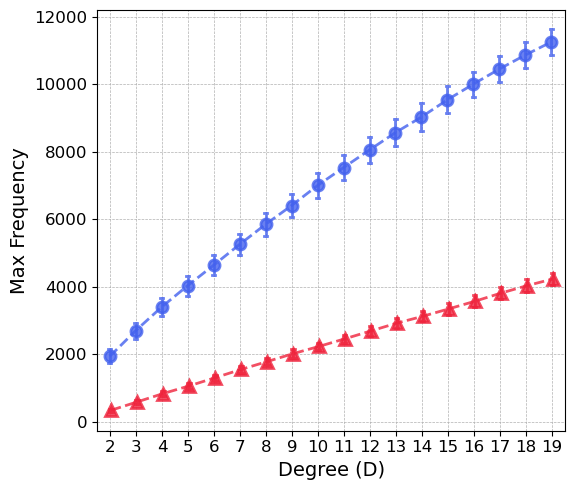

In [11]:
# Set the aesthetic style of the plots
#sns.set(style="whitegrid")

# Define a custom color palette
palette = sns.color_palette(["#4361ee", "#ef233c"])  # Blue and red for contrast

# Create the pointplot with enhanced aesthetics
plt.figure(figsize=(5.85, 5))
sns.pointplot(x='Degree (d)', y='Max Frequency', hue='Method', data=df, 
              palette=palette, markers=["o", "^"], linestyles=["--", "--"], 
              dodge=True, ci="sd", linewidth=2, markeredgewidth=2, markersize=8, capsize=0.125, alpha=0.8, legend=False)

# Add grid lines and labels
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlabel('Degree (D)', fontsize=14)
plt.ylabel('Max Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Adjust legend position and style
#plt.legend(loc='upper left', frameon=True, fontsize=12, fancybox=True, shadow=True)

# Tight layout to minimize padding
plt.tight_layout()
plt.savefig('freq_diff_qaoa1_deg2.pdf', bbox_inches='tight')

# Display the plot
plt.show()

In [7]:
# Set the aesthetic style of the plots
#sns.set(style="whitegrid")

# Define a custom color palette
palette = sns.color_palette(["#4361ee", "#ef233c"])  # Blue and red for contrast

# Create the pointplot with enhanced aesthetics
plt.figure(figsize=(6, 5))
sns.pointplot(x='Degree (d)', y='Max Frequency', hue='Method', data=df2, 
              palette=palette, markers=["o", "^"], linestyles=["--", "--"], 
              dodge=True, ci="sd", linewidth=2, markeredgewidth=2, markersize=8, capsize=0.25, alpha=0.8)

# Add grid lines and labels
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlabel('# Nodes', fontsize=14)
plt.ylabel('Max Frequency', fontsize=14)

# Increase tick size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Adjust legend position, style, and set title to empty
plt.legend(title='', loc='upper left', frameon=True, fontsize=14, fancybox=True, shadow=True)

# Tight layout to minimize padding
plt.tight_layout()
plt.savefig('freq_diff_qaoa1_nodes.pdf', bbox_inches='tight')

# Display the plot
plt.show()


NameError: name 'df2' is not defined

<Figure size 600x500 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
#sns.set(style="whitegrid")

# Define a custom color palette
palette = sns.color_palette(["#4A90E2", "#D0021B"])  # Slightly muted blue and red for contrast

# Create the pointplot with enhanced aesthetics
plt.figure(figsize=(6, 5))
sns.pointplot(x='Degree (d)', y='Max Frequency', hue='Method', data=df2, 
              palette=palette, markers=["o", "^"], linestyles=["-", "--"], 
              dodge=True, ci="sd", linewidth=2.5, markeredgewidth=2, markersize=10, alpha=0.8)

# Add grid lines and labels
plt.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
plt.minorticks_off()  # Removes minor ticks for a cleaner look
plt.xlabel('# Nodes', fontsize=14, labelpad=10)  # Added padding for better spacing
plt.ylabel(r'Max Frequency ($\omega_{\max}$)', fontsize=14, labelpad=10)

# Adjust legend position and style
plt.legend(loc='upper left', frameon=True, fontsize=12, fancybox=True, shadow=True, title="Method", title_fontsize='13')

# Annotate a few key points
for line in plt.gca().get_lines():
    for x, y in line.get_xydata():
        if y == max(line.get_ydata()):  # Annotate max values
            plt.text(x, y, f'{int(y)}', color=line.get_color(), fontsize=10, ha='center', va='bottom')

# Tight layout to minimize padding
plt.tight_layout()
# Display the plot
plt.show()
